
<div align="center">

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/xiangtgao/DS-UA_201-Causal-Inference-Spring-2025/blob/main/labs/2-Probability.ipynb)

</div>






$$
\begin{array}{c}
\textbf{CAUSAL INFERENCE}\\\\
\textbf{Hamza Alshamy} \\
\textit{Center for Data Science, New York University} \\\\
\textit{September 12, 2025}\\\\\\
\text{Materials prepared by: Daniela Pinto Veizaga, Xiang Pan, and Xiang Gao}
\end{array}
$$

---

## Joint Probability

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv(f"2-data.csv")
df

,Height,Weight,Sex
0,165.65,35.41,Female
1,148.53,74.45,Female
2,167.04,81.22,Male
3,161.54,71.47,Male
4,174.31,78.18,Male
...,...,...,...
2995,150.83,49.66,Female
2996,157.09,64.34,Female
2997,162.99,45.58,Female
2998,154.76,48.92,Female


- In a **univariate** case:

\begin{align}
&P(X = x), \qquad (\text{Discrete})\\
&f_X(x), \qquad (\text{Continuous})
\end{align}

**Note:** $P(X = x)$ is a probability whereas $f_X(x)$ is a density.

- In a **Joint Distribution**:

\begin{align}
&P(X = x, Y = y), \qquad (\text{Discrete})\\
&f_{X,Y}(x,y), \qquad (\text{Continuous})
\end{align}

## Joint Distribution

In [3]:
df

,Height,Weight,Sex
0,165.65,35.41,Female
1,148.53,74.45,Female
2,167.04,81.22,Male
3,161.54,71.47,Male
4,174.31,78.18,Male
...,...,...,...
2995,150.83,49.66,Female
2996,157.09,64.34,Female
2997,162.99,45.58,Female
2998,154.76,48.92,Female


The data is continuous, but we can bin it to make it discrete.

\begin{align}
P(X = x, Y = y) = \frac{N_{x,y}}{N}
\end{align}

We want to know what's the probability of height larger than $h$ and gender is male.

\begin{align}
P(H > h, G = M) = \frac{N_{h, M}}{N}
\end{align}

In [4]:
h = 180
g = "Male"

group = df[(df["Height"] > h) & (df["Sex"] == g)]
print(f"The probability of a person being {g} and taller than {h} cm is {(len(group) / len(df))*100:.2f}%")

The probability of a person being Male and taller than 180 cm is 8.47%


## Convert the Joint Distribution to Marginal Distribution

Generally, a joint probability over two variables is defined as:


**Discrete Case:**

If we have two discrete random variables $A$ and $B$, then the **marginal PMF of $A$** is obtained by summing over all possible values of $B$:

\begin{align}
P(\underbrace{A = a}_{\text{Fixed}}) 
&= \sum_{b \in \mathcal{B}} 
   P\big(\underbrace{A = a}_{\text{Fixed}},\;
     \underbrace{B = b}_{\text{All values of $B$}} \big).
\end{align}

$$
P(A= 3) = \sum_{b \in \mathcal{B}} 
   P\big(\underbrace{A = 3}_{\text{Fixed}},\;
     \underbrace{B = b}_{\text{All values of $B$}} \big).
$$

**Continuous Case:** 

If $A$ and $B$ are continuous, then the **marginal PDF of $A$** is obtained by integrating out $B$:

\begin{align}
f_A(a) 
&= \int_{-\infty}^{\infty} 
   f_{A,B}\big(\underbrace{a}_{\text{Fixed}},\;
               \underbrace{b}_{\text{All values of $B$}}\big)\, db.
\end{align}

Let's look at an example with our dataset:

**What is the probability of height larger than some $h$?**

We can sum over all the genders.

\begin{align}
P(H > h) &= \sum_{g \in \{\text{male}, \text{female}\}} P(H > h, G = g) = \sum_{g} \frac{N_{h,g}}{N}
\end{align}

- In English: 


In [5]:
# We want the marginal probability of height greater than 180 cm
# So, since we are dealing with a dataset, we can compute it directly by
# counting the number of people taller than 180 cm and dividing by the total number of people
h = 180

group_male_height = df[(df["Height"] > h) & (df["Sex"] == "Male")]
group_female_height = df[(df["Height"] > h) & (df["Sex"] == "Female")]

print(f"The probability of a person being male and taller than {h} cm is {len(group_male_height) / len(df)}")
print(f"The probability of a person being female and taller than {h} cm is {len(group_female_height) / len(df)}")

The probability of a person being male and taller than 180 cm is 0.08466666666666667
The probability of a person being female and taller than 180 cm is 0.0016666666666666668


**What is the marginal probability of being taller than some $h$?**

In [6]:
group_height = df[df["Height"] > h]
print(f"The probability of a person being taller than {h} cm is {len(group_height) / len(df)}")

# we can verify: Male height greater than 180 + female height greater than 180
p = len(group_male_height) / len(df) + len(group_female_height) / len(df)
print(f"The probability of a person being taller than {h} cm is {p}")

The probability of a person being taller than 180 cm is 0.08633333333333333
The probability of a person being taller than 180 cm is 0.08633333333333333


## Variance of x
$$
\operatorname{Var}(X) = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu_x)^2
$$

### Properties
<!-- \operatorname{Var}(X+Y)=\operatorname{Var}(X)+\operatorname{Var}(Y)+2 \operatorname{Cov}(X, Y) -->
$$
\operatorname{Var}(X+Y) = \operatorname{Var}(X) + \operatorname{Var}(Y) + 2 \operatorname{Cov}(X, Y)
$$
$$
\operatorname{Var}(X-Y) = \operatorname{Var}(X) + \operatorname{Var}(Y) - 2 \operatorname{Cov}(X, Y)
$$
$$
\operatorname{Var}(aX + bY) = a^2 \operatorname{Var}(X) + b^2 \operatorname{Var}(Y) + 2ab \operatorname{Cov}(X, Y)
$$



$$
\begin{aligned}
\operatorname{Var}(X + Y) &= E[(X + Y - E[X + Y])^2] && \text{(Definition of variance)} \\
&= E[(X + Y - (E[X] + E[Y]))^2] && \text{(Substitute } E[X + Y] = E[X] + E[Y]) \\
&= E[(X - E[X] + Y - E[Y])^2] && \text{(Rearrange terms)} \\
&= E[(X - E[X])^2] + E[(Y - E[Y])^2] + 2E[(X - E[X])(Y - E[Y])] && \text{(Expand the square)} \\
&= \operatorname{Var}(X) + \operatorname{Var}(Y) + 2 \operatorname{Cov}(X, Y)
\end{aligned}
$$

## Covariance

### From Variance to Covariance

Recall that variance is defined as:

$$
\operatorname{Var}(X) = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu_x)^2
$$

We can also write variance as:

$$
\operatorname{Var}(X) = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu_x)(x_i - \mu_x)
$$

Instead of having $(x_i - \mu_x)$ twice, we can generalize to two variables:

$$
\boxed{\operatorname{Cov}(X, Y) = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu_x)(y_i - \mu_y)}
$$

- **Covariance** is an (unnormalized) measure of the linear relationship between two variables.

**Theoretical Definition of Covariance:**
\begin{align}
Cov(X, Y)
= E[(X - E[X])(Y - E[Y])]
= E[XY] - E[X]E[Y]
\end{align}

### Properties of Covariance
1. **Symmetry**  
$$
\text{Cov}(X, Y) = \text{Cov}(Y, X)
$$  
Covariance is symmetric in its arguments.  

2. **Constant with a variable**  
$$
\text{Cov}(X, a) = 0
$$  
A random variable and a constant have zero covariance.  

3. **Additivity**  
$$
\text{Cov}(X+Y, Z) = \text{Cov}(X, Z) + \text{Cov}(Y, Z)
$$  
Covariance distributes over addition.  

4. **Scaling**  
$$
\text{Cov}(a+bX, Y) = b \, \text{Cov}(X, Y)
$$  
Multiplying a variable by a constant scales the covariance by that constant.  

https://numpy.org/doc/stable/reference/generated/numpy.cov.html

In [7]:
X = np.random.randn(1000)
Y = 2 * X + 1
print(np.cov(X, Y))

[[1.01098227 2.02196453]
 [2.02196453 4.04392907]]


In [8]:
height = df["Height"]

In [9]:
# Extract the height and weight columns as arrays



height = df["Height"].values
weight = df["Weight"].values

# Compute the sample covariance matrix
# By default, np.cov uses ddof=1 (divides by N-1, the sample covariance)
cov_matrix = np.cov(height, weight)

print("Covariance matrix (Height, Weight):")
print(cov_matrix)

# If you want the covariance value directly (off-diagonal entry):
cov_hw = cov_matrix[0, 1]
print(f"Cov(Height, Weight) = {cov_hw}")

Covariance matrix (Height, Weight):
[[3015.4066601    32.77766496]
 [  32.77766496  290.41366482]]
Cov(Height, Weight) = 32.777664961387124


$$
\widehat{Cov}(X, Y) = \frac{1}{N-1} \sum_{i=1}^{N} (x_i - \bar{x})(y_i - \bar{y})
$$

## Correlation

**Covariance** has the unit of the product of the two variables.

If $X$ is measured in centimeters (cm) and $Y$ in kilograms (kg):

$$
\operatorname{Cov}(X, Y) \approx 32.8 \; (\text{cm} \cdot \text{kg})
$$

Normalization by the standard deviations produces a unitless measure:

$$
\rho_{X, Y} = \frac{\operatorname{Cov}(X, Y)}{\sqrt{\operatorname{Var}(X)\,\operatorname{Var}(Y)}}, \qquad \rho_{X, Y} \in [-1, 1]
$$

**Correlation** measures the strength and direction of the *linear relationship* between two variables, on a standardized scale from -1 to 1.

## Correlation $\not\implies$ Causation

![alt text](ice_cream_murder.png)

[Link to Article](https://slate.com/news-and-politics/2013/07/warm-weather-homicide-rates-when-ice-cream-sales-rise-homicides-rise-coincidence.html)

**Causal Graph (DAG)**

We can represent this situation with a **directed acyclic graph (DAG)**, where:
- $W=1$ Hot Weather
- $I=1$ Ice Cream Sales
- $D=1$ Drowning Incidents

The causal relationships are:
- $W \rightarrow I$ (Hot weather increases ice cream sales)
- $W \rightarrow D$ (Hot weather increases the likelihood of drowning incidents)

/var/folders/14/d8fzd0c94rqd5rwglx3fw6d80000gn/T/ipykernel_22178/3898922254.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


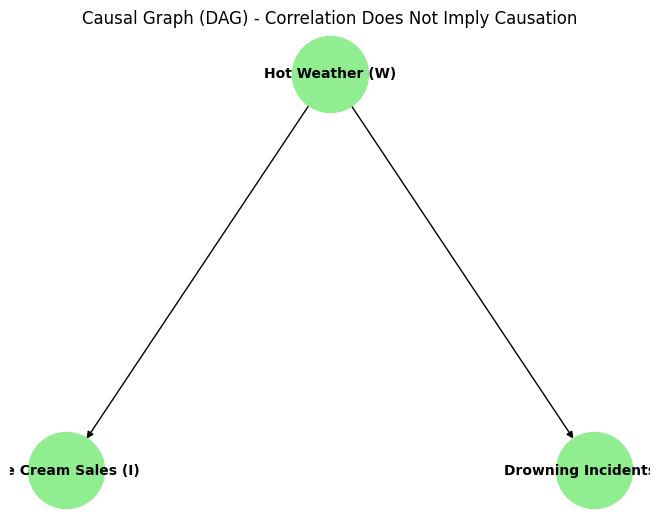

In [10]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add nodes
G.add_node("Hot Weather (W)")
G.add_node("Ice Cream Sales (I)")
G.add_node("Drowning Incidents (D)")

# Add directed edges representing causal relationships
G.add_edge("Hot Weather (W)", "Ice Cream Sales (I)")
G.add_edge("Hot Weather (W)", "Drowning Incidents (D)")

# Draw the graph
pos = {
    "Hot Weather (W)": (0, 1),
    "Ice Cream Sales (I)": (-1, 0),
    "Drowning Incidents (D)": (1, 0),
}

nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightgreen", font_size=10, font_weight="bold", arrows=True)
plt.tight_layout()

plt.title("Causal Graph (DAG) - Correlation Does Not Imply Causation")
plt.show()


Correlation between Ice Cream Sales and Drowning Incidents: 0.1812
Correlation between Ice Cream Sales and Hot Weather: 0.7026
Correlation between Drowning Incidents and Hot Weather: 0.2395

Drowning rates by Ice Cream Sales:
Ice Cream Sales
0    0.046310
1    0.152104
Name: Drowning Incidents, dtype: float64


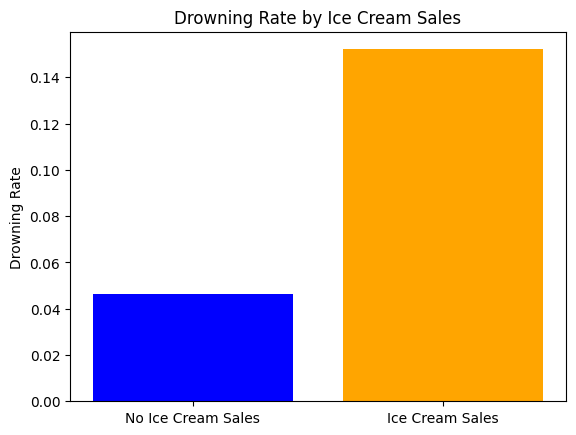

In [11]:
# Number of individuals (or time periods)
n = 1000

# Probability of hot weather
p_hot_weather = 0.3

# Ice cream sales probabilities (conditional on weather)
p_ice_cream_if_hot = 0.8
p_ice_cream_if_not_hot = 0.1

# Drowning incidents probabilities (conditional on weather)
p_drowning_if_hot = 0.2
p_drowning_if_not_hot = 0.05

# Simulate Hot Weather
np.random.seed(42)
hot_weather = np.random.binomial(1, p_hot_weather, n)

# Simulate Ice Cream Sales based on weather
ice_cream_sales = np.where(hot_weather == 1,
                           np.random.binomial(1, p_ice_cream_if_hot, n),
                           np.random.binomial(1, p_ice_cream_if_not_hot, n))

# Simulate Drowning Incidents based on weather
drowning_incidents = np.where(hot_weather == 1,
                              np.random.binomial(1, p_drowning_if_hot, n),
                              np.random.binomial(1, p_drowning_if_not_hot, n))

# Create a DataFrame for analysis
df = pd.DataFrame({
    'Hot Weather': hot_weather,
    'Ice Cream Sales': ice_cream_sales,
    'Drowning Incidents': drowning_incidents
})

# Calculate correlations
correlation_ice_drowning = df[['Ice Cream Sales', 'Drowning Incidents']].corr().iloc[0, 1]
correlation_ice_weather = df[['Ice Cream Sales', 'Hot Weather']].corr().iloc[0, 1]
correlation_drowning_weather = df[['Drowning Incidents', 'Hot Weather']].corr().iloc[0, 1]

# Print correlation results
print(f"Correlation between Ice Cream Sales and Drowning Incidents: {correlation_ice_drowning:.4f}")
print(f"Correlation between Ice Cream Sales and Hot Weather: {correlation_ice_weather:.4f}")
print(f"Correlation between Drowning Incidents and Hot Weather: {correlation_drowning_weather:.4f}")

# Grouped statistics to check rates
ice_cream_drowning_rate = df.groupby('Ice Cream Sales')['Drowning Incidents'].mean()
print("\nDrowning rates by Ice Cream Sales:")
print(ice_cream_drowning_rate)

# Plot the results
plt.bar(['No Ice Cream Sales', 'Ice Cream Sales'], ice_cream_drowning_rate, color=['blue', 'orange'])
plt.title('Drowning Rate by Ice Cream Sales')
plt.ylabel('Drowning Rate')
plt.show()


## Causation $\not\implies$ Correlation

**What we know:**
- Antihistamines causally reduce sneezing

- People taking antihistamines sneeze more than average

- Negative causal effect of antihistamines on sneezing but

- positive correlation b/w antihistamine use and sneezing

- $A=1$ if a person takes antihistamines, 0 otherwise.
- $S=1$ if a person sneezes, 0 otherwise.
- $C=1$ if a person has the underlying condition (e.g., allergies), 0 otherwise.

**Assumptions:**
1. $A$ and $S$ are dependent on $C$, meaning:
- People with allergies $(C=1)$ are more likely to take antihistamines.
- People with allergies $(C=1)$ sneeze more frequently.
1. Negative causal effect of antihistamines: Antihistamines reduce sneezing, i.e., $P(S=1 \mid A=1, C=1)<P(S=1 \mid A=0, C=1)$.

Model:
We can model the probability of sneezing $S$ as a function of antihistamine use $A$, the underlying condition $C$, and their relationships:

$$
P(S=1 \mid A=a, C=c)=\alpha_c-\beta \cdot a
$$

where:
- $\alpha_c$ captures the baseline sneezing rate based on the condition $C$.
- $\beta$ captures the reduction in sneezing due to antihistamines.

Similarly, we can model the probability of taking antihistamines as a function of the underlying condition:

$$
P(A=1 \mid C=c)=\gamma \cdot c
$$


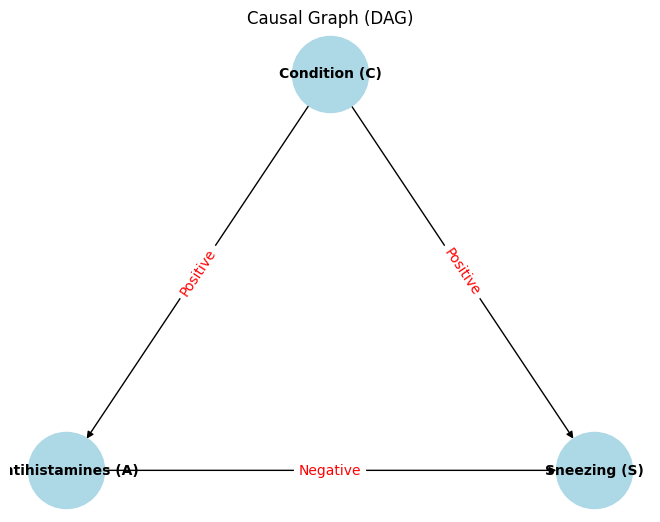

In [12]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add nodes
G.add_node("Condition (C)")
G.add_node("Antihistamines (A)")
G.add_node("Sneezing (S)")

# Add directed edges representing causal relationships
G.add_edge("Condition (C)", "Antihistamines (A)")
G.add_edge("Condition (C)", "Sneezing (S)")
G.add_edge("Antihistamines (A)", "Sneezing (S)")

# Draw the graph
pos = {
    "Condition (C)": (0, 1),
    "Antihistamines (A)": (-1, 0),
    "Sneezing (S)": (1, 0),
}

labels = {
    ("Condition (C)", "Antihistamines (A)"): "Positive",
    ("Condition (C)", "Sneezing (S)"): "Positive",
    ("Antihistamines (A)", "Sneezing (S)"): "Negative",
}

nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=10, font_weight="bold", arrows=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_color="red")

plt.title("Causal Graph (DAG)")
plt.show()


Correlation between antihistamine use and sneezing: 0.2137

Average sneezing rates:
Antihistamines
0    0.112332
1    0.309392
Name: Sneezing, dtype: float64


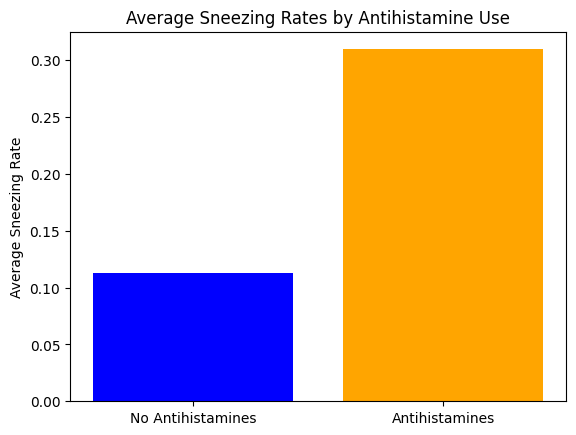

In [13]:
# Number of individuals
n = 1000

# Parameters
p_condition = 0.2  # Probability of having the underlying condition (allergies)
alpha_c1 = 0.8     # Sneezing rate with condition and without antihistamines
alpha_c0 = 0.1     # Sneezing rate without condition
beta = 0.5         # Effect of antihistamines on sneezing
gamma = 0.9        # Probability of taking antihistamines with the condition

# Simulate data
np.random.seed(42)
C = np.random.binomial(1, p_condition, n)  # Condition presence
A = np.random.binomial(1, gamma * C)       # Antihistamine use based on condition

# Sneezing probability based on condition and antihistamine use
sneezing_prob = np.where(C == 1, alpha_c1 - beta * A, alpha_c0)
S = np.random.binomial(1, sneezing_prob)  # Sneezing occurrences

# Create a DataFrame for analysis
df = pd.DataFrame({'Condition': C, 'Antihistamines': A, 'Sneezing': S})

# Calculate correlations
correlation = df[['Antihistamines', 'Sneezing']].corr().iloc[0, 1]

# Print results
print(f"Correlation between antihistamine use and sneezing: {correlation:.4f}")

# Grouped statistics to check average sneezing rates
sneezing_rates = df.groupby('Antihistamines')['Sneezing'].mean()
print("\nAverage sneezing rates:")
print(sneezing_rates)

# Plot the results
plt.bar(['No Antihistamines', 'Antihistamines'], sneezing_rates, color=['blue', 'orange'])
plt.title('Average Sneezing Rates by Antihistamine Use')
plt.ylabel('Average Sneezing Rate')
plt.show()

## Law of Iterated Expectations

Sometimes we do not have direct access to $\mathbb{E}[X]$, but we can compute or assume $\mathbb{E}[X \mid Y]$.  
The **Law of Iterated Expectations** allows us to recover the expectation from the conditional one:

$$
\boxed{\mathbb{E}[X] = \mathbb{E}[\mathbb{E}[X \mid Y]]}.
$$

Trivial Proof:

\begin{align}
\mathbb{E}[\mathbb{E}(X \mid Y)] & =\mathbb{E}\left[\sum_{x \in \mathcal{X}} x \cdot \operatorname{Pr}(X=x \mid Y)\right] \\
& =\sum_{y \in \mathcal{Y}}\left[\sum_{x \in \mathcal{X}} x \cdot \operatorname{Pr}(X=x \mid Y=y)\right] \cdot \operatorname{Pr}(Y=y) \\
& =\sum_{x \in \mathcal{X}} \sum_{y \in \mathcal{Y}} x \cdot \operatorname{Pr}(X=x \mid Y=y) \cdot \operatorname{Pr}(Y=y) \\
& =\sum_{x \in \mathcal{X}} \sum_{y \in \mathcal{Y}} x \cdot \operatorname{Pr}(X=x, Y=y) \\
& =\sum_{x \in \mathcal{X}} x \sum_{y \in \mathcal{Y}} \operatorname{Pr}(X=x, Y=y) \\
& =\sum_{x \in \mathcal{X}} x \cdot \operatorname{Pr}(X=x) \\
& =\mathbb{E}(X)
\end{align}

## Independence

### Independence in terms of Events


Two events $A$ and $B$ are independent if knowing that one occurred 
does not change the probability of the other:

$$
P(A \cap B) = P(A) \cdot P(B).
$$

**Note:** Without Independence:

$$
P(A \cap B) = P(A) \cdot P(B \mid A).
$$
---

### Independce in terms of Random Variables


$$
P(X \in A, Y \in B) = P(X \in A)P(Y \in B)
$$

**In English:** The probability that $X$ takes a value in set $A$ **and** $Y$ takes a value in set $B$ equals the probability that $X$ takes a value in $A$ multiplied by the probability that $Y$ takes a value in $B$.  

This expresses independence: knowing where $X$ lands does not change the probability of where $Y$ lands (and vice versa).
Also,

$$
P(Y|X) = P(Y) \ \ \text{and} \ \ P(X|Y) = P(X)
$$

If two variables are independent, then knowing the value of one variable does not provide additional information about the other.

It is also the case that independent variables have a covariance of 0 and are, therefore, uncorrelated.


Let's go through some simulations!

- **If $X$ and $Y$ are independent:**

$$
\mathbb{E}[XY] = \mathbb{E}[X]\mathbb{E}[Y] \quad \implies \quad \operatorname{Cov}(X,Y) = 0 \quad \implies \quad \rho_{X,Y} = 0
$$

Independence always implies lack of correlation.

In [14]:
# Step 1: Simulate independent random variables
np.random.seed(201)
X_ind = np.random.randint(1, 7, 1000)  # Roll of die 1
Y_ind = np.random.randint(1, 7, 1000)  # Roll of die 2

# Step 2: Calculate covariance of independent variables
cov_ind = np.cov(X_ind, Y_ind)[0, 1]
print(f"Covariance of independent variables: {cov_ind}")

# Step 3: Simulate dependent variables
# The dependence comes from Y being a function of X
X_dep = np.random.randint(1, 10, 1000)
Y_dep = 2 * X_dep + np.random.normal(0, 1, 1000)

# Calculate covariance of dependent variables
cov_dep = np.cov(X_dep, Y_dep)[0, 1]
print(f"Covariance of dependent variables: {cov_dep}")

Covariance of independent variables: -0.09712712712712716
Covariance of dependent variables: 12.798416177120508


We see that independence implies 0 covariance and uncorrelatedness.

However, the converse statement is false. Independence is not necessary for uncorrelatedness.

- **If $X$ and $Y$ are uncorrelated ($\rho = 0$):**

  - This does not guarantee independence.  
  - They may still have a strong nonlinear dependence.  

Correlation between X and Y: -0.000


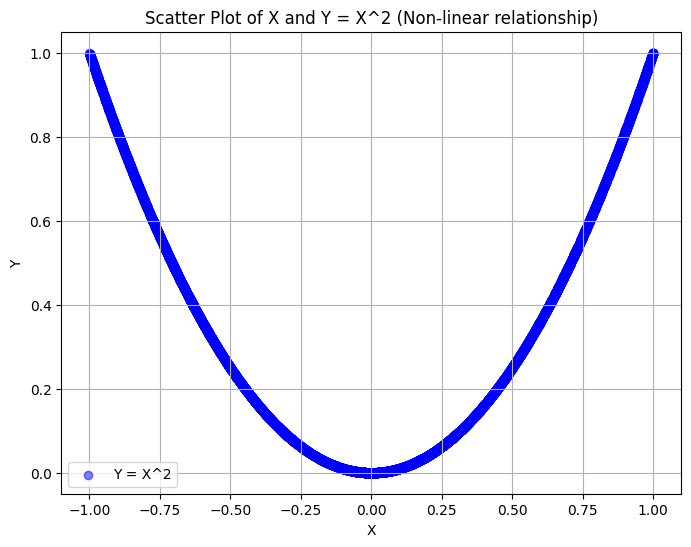

In [15]:
# Generate X uniformly from [-1, 1]
np.random.seed(201)
X = np.random.uniform(-1, 1, 10000)

# Define Y as X^2
# Y is fully determined by X, but the relationship is non-linear
Y = X**2

# Calculate correlation
corr_XY = np.corrcoef(X, Y)[0, 1]
print(f"Correlation between X and Y: {corr_XY:.3f}")

# Create a scatter plot to visualize the relationship between X and Y
plt.figure(figsize=(8, 6))
plt.scatter(X, Y, color='blue', alpha=0.5, label='Y = X^2')
plt.title('Scatter Plot of X and Y = X^2 (Non-linear relationship)')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.legend()
plt.show()